# Recreation of Section 5. Model Validation from *Model design for networks of heterogeneous Hodgkin–Huxley neurons* by Giannari et al.
Source: https://www.sciencedirect.com/science/article/pii/S0925231222005148#t0010

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pickle
from pathlib import Path
from datetime import datetime

In [4]:
NEURON_TYPE_PARAMS = {
    # Initial HH Model parameters taken from Table 2:
    # Capacitor
    "C_M": {"FS": 0.5, "RSA": 1.0, "IB": 1.0},

    # Conductances
    "g_bar_K": {"FS": 10.0, "RSA": 6.0, "IB": 5.0},
    "g_bar_M": {"FS": 0.0, "RSA": 0.075, "IB": 0.03},
    "g_bar_Ca": {"FS": 0.0, "RSA": 0.0, "IB": 0.2},
    "g_bar_Na": {"FS": 56.0, "RSA": 56.0, "IB": 50.0},
    "g_L": {"FS": 0.015, "RSA": 0.0205, "IB": 0.01},

    "tau_max": {"FS": 1.0, "RSA": 608.0, "IB": 608.0},

    # Resting potentials
    "V_K": {"FS": -90.0, "RSA": -90.0, "IB": -90.0},
    "V_Ca": {"FS": 0.0, "RSA": 0.0, "IB": 120.0},
    "V_Na": {"FS": 50.0, "RSA": 56.0, "IB": 50.0},
    "V_L": {"FS": -70.0, "RSA": -70.3, "IB": -70.0},
    "V_T": {"FS": -56.2, "RSA": -56.2, "IB": -56.2},     # threshold adjustment for FS neurons

    # Synapse parameters taken from Table 3:
    "tau_r": {"FS": 0.5, "RSA": 0.5, "IB": 0.5},        # rise time
    "tau_d": {"FS": 8.0, "RSA": 8.0, "IB": 8.0},        # decay time
    "V_syn": {"FS": -80.0, "RSA": 20.0, "IB": 20.0},    # reversal potential of the synapse
    "V_0": {"FS": -20.0, "RSA": -20.0, "IB": -20.0},    # reversal potential
}

def generate_simulation_params(param_dict, neuron_types):
    return np.array([[param_dict[nt]] for nt in neuron_types], dtype=float)

Generate alpha and beta rate terms for each gate

In [5]:
def get_rates(gate_type: str, V, V_T):
    # Gates used in all neuron types
    if gate_type == "n":
        common_term = V - V_T - 15
        alpha = (common_term * -0.032) / (np.exp(-common_term / 5) - 1)
        beta = 0.5 * np.exp(-(V - V_T - 10) / 40)

    elif gate_type == "m":
        common_term = V - V_T - 13
        alpha = (common_term * -0.32) / (np.exp(-common_term / 4) - 1)
        beta = 0.28 * (np.exp(-(V - V_T - 40) / 5)) - 1

    elif gate_type == "h":
        alpha = 0.128 * np.exp(-(V - V_T - 17) / 18)
        beta = 4 / (np.exp(-(V - V_T - 40) / 5) + 1)

    # Additional gates for IB Neuron type
    elif gate_type == "q":
        common_term = -27 - V
        alpha = 0.0055 * common_term / (np.exp(common_term / 3.8) - 1)
        beta = 0.0065 / (np.exp((-15 - V) / 28) + 1)

    elif gate_type == "s":
        alpha = 0.000457 * np.exp((-13 - V) / 50)
        beta = 0.94 * np.exp((-75 - V) / 17)

    return alpha, beta

# Steady state for the additional gate requried for the RSA neuron type
def get_p_inf(V):
    p_inf = 1 / (np.exp(-(V + 35) / 10) + 1)
    return p_inf

Heterogenous Hodgkin-Huxley Model that uses vectorized network equation to describe multiple neuron interactions

In [6]:
class HeterogeneousHH():
    def __init__(
            self,
            N,
            C_M,
            g_bar_K,
            g_bar_M,
            g_bar_Ca,
            g_bar_Na,
            g_L,
            V_K,
            V_Ca,
            V_Na,
            V_L,
            V_T,
            V_syn,
            tau_max,
            tau_r,
            tau_d,
            V_0,
            L_el,   # Laplacian of electrical synapses
            A_ch,   # Adjacency matrix of chemical synapses
            V_init,
            n_init,
            m_init,
            h_init,
            p_init,
            q_init,
            s_init,
            r_init,
            synaptic_scaling,
            voltage_threshold=-20,
            target_firing_rate=0,
            tau_rate_ms = 2000.0,   # used to calculate alpha for EMA
            ema_alpha = 0.05,       # use this if you want to plug it in directly
            eta=1e-3,
            S_min=0.1,              # min scaling factor
            S_max=2.0               # max scaling factor
    ):
        # Injected current
        self.injected_current = 0.0

        # neuron/model parameters
        self.N = N
        self.C_M = C_M
        self.g_bar_K = g_bar_K
        self.g_bar_M = g_bar_M
        self.g_bar_Ca = g_bar_Ca
        self.g_bar_Na = g_bar_Na
        self.g_L = g_L
        self.V_K = V_K
        self.V_Ca = V_Ca
        self.V_Na = V_Na
        self.V_L = V_L
        self.V_T = V_T
        self.V_syn = V_syn
        self.tau_max = tau_max
        self.tau_r = tau_r
        self.tau_d = tau_d
        self.V_0 = V_0
        self.L_el = L_el
        self.A_ch = A_ch

        # Save initial values
        self.V_init = V_init.copy()
        self.n_init = n_init.copy()
        self.m_init = m_init.copy()
        self.h_init = h_init.copy()
        self.p_init = p_init.copy()
        self.q_init = q_init.copy()
        self.s_init = s_init.copy()
        self.r_init = r_init.copy()


        # Start with initial values
        self.V = V_init.copy()
        self.n = n_init.copy()
        self.m = m_init.copy()
        self.h = h_init.copy()
        self.p = p_init.copy()
        self.q = q_init.copy()
        self.s = s_init.copy()
        self.r = r_init.copy()

        self.V_history = [V_init]
        self.n_history = [n_init]
        self.m_history = [m_init]
        self.h_history = [h_init]
        self.p_history = [p_init]
        self.q_history = [q_init]
        self.s_history = [s_init]
        self.r_history = [r_init]
        self.A_ch_history = [A_ch]
        self.spike_history = []
        self.spike_ema_Hz_history = []
        self.scaling_factor_history = []
        self.error_history = []             # integrated errors for firing rate deviations

        # track spikes
        self.synaptic_scaling = synaptic_scaling
        self.voltage_threshold = voltage_threshold
        self.target_firing_rate = target_firing_rate
        self.refracting = np.zeros(self.N, dtype=bool)
        self.has_spiked_once = np.zeros(self.N, dtype=bool)
        self.tau_rate_ms = tau_rate_ms
        self.ema_alpha = ema_alpha
        self.eta = eta
        self.spike_ema = np.zeros(self.N, dtype=float)
        self.S = np.ones(self.N, dtype=float)          # one scaling factor per postsynaptic neuron
        self.S_min = S_min
        self.S_max = S_max
        self.A_ch_base = self.A_ch.copy()

    # Gates used in all neuron types
    def dndt(self):
        alpha, beta = get_rates("n", self.V, self.V_T)
        return alpha * (1 - self.n) - beta * self.n

    def dmdt(self):
        alpha, beta = get_rates("m", self.V, self.V_T)
        return alpha * (1 - self.m) - beta * self.m

    def dhdt(self):
        alpha, beta = get_rates("h", self.V, self.V_T)
        return alpha * (1 - self.h) - beta * self.h

    # Additional gate for the RSA neuron type
    def dpdt(self):
        p_inf = get_p_inf(self.V)
        tau_p = self.tau_max / (
            3.3 * np.exp((self.V + 35) / 20) + np.exp(-(self.V + 35) / 20)
        )

        return (p_inf - self.p) / tau_p

    # Additional gates for IB Neuron type
    def dqdt(self):
        alpha, beta = get_rates("q", self.V, self.V_T)
        return alpha * (1 - self.q) - beta * self.q

    def dsdt(self):
        alpha, beta = get_rates("s", self.V, self.V_T)
        return alpha * (1 - self.s) - beta * self.s

    # Fraction of receptors bound to neurotransmitters
    def drdt(self):
        return (
            ((1 / self.tau_r) - (1 / self.tau_d))
            * ((1 - self.r) / (1 + np.exp(-self.V + self.V_0)))
            - (self.r / self.tau_d)
        )

    # Combined Feedback of both electrical and chemical synapses
    def u(self):
        # electrical (unchanged)
        u_el = -self.L_el @ self.V

        # shapes:
        # V: (N,1)
        # r: (N,1)
        # V_syn: (N,1)

        r_pre = self.r.T            # (1, N)
        Vsyn_pre = self.V_syn.T     # (1, N)
        V_post = self.V             # (N, 1)

        # build matrix: r_j * (V_syn_j - V_i)
        M = r_pre * (Vsyn_pre - V_post)   # (N, N)

        # apply adjacency and sum over presynaptic neurons
        u_ch = np.sum(self.A_ch * M, axis=1, keepdims=True)

        return u_el + u_ch

    def dVdt(self):
        return (np.ones((self.N, 1)) / self.C_M) * (
            self.injected_current
            - self.g_bar_K * self.n**4 * (self.V - self.V_K)
            - self.g_bar_M * self.p * (self.V - self.V_K)
            - self.g_bar_Ca * self.q**2 * self.s * (self.V - self.V_Ca)
            - self.g_bar_Na * self.m**3 * self.h * (self.V - self.V_Na)
            - self.g_L * (self.V - self.V_L)
            + self.u()
        )

    def step(self, dt, injected_current, time):
        self.injected_current = injected_current

        # compute all derivatives using the current state
        dV = self.dVdt()
        dn = self.dndt()
        dm = self.dmdt()
        dh = self.dhdt()
        dp = self.dpdt()
        dq = self.dqdt()
        ds = self.dsdt()
        dr = self.drdt()

        # Euler update
        self.V = self.V + dV * dt
        self.n = self.n + dn * dt
        self.m = self.m + dm * dt
        self.h = self.h + dh * dt
        self.p = self.p + dp * dt
        self.q = self.q + dq * dt
        self.s = self.s + ds * dt
        self.r = self.r + dr * dt

        # clip voltage to prevent exp overflow
        self.V = np.clip(self.V, -100, 100)

        # clip gating variables to valid range
        self.n = np.clip(self.n, 0.0, 1.0)
        self.m = np.clip(self.m, 0.0, 1.0)
        self.h = np.clip(self.h, 0.0, 1.0)
        self.p = np.clip(self.p, 0.0, 1.0)
        self.q = np.clip(self.q, 0.0, 1.0)
        self.s = np.clip(self.s, 0.0, 1.0)
        self.r = np.clip(self.r, 0.0, 1.0)

        # remove NaNs
        self.V = np.nan_to_num(self.V)
        self.n = np.nan_to_num(self.n)
        self.m = np.nan_to_num(self.m)
        self.h = np.nan_to_num(self.h)
        self.p = np.nan_to_num(self.p)
        self.q = np.nan_to_num(self.q)
        self.s = np.nan_to_num(self.s)
        self.r = np.nan_to_num(self.r)

        self.V_history.append(self.V.copy())
        self.n_history.append(self.n.copy())
        self.m_history.append(self.m.copy())
        self.h_history.append(self.h.copy())
        self.p_history.append(self.p.copy())
        self.q_history.append(self.q.copy())
        self.s_history.append(self.s.copy())
        self.r_history.append(self.r.copy())

        # check if voltage passed threshold and spiked
        V_flat = self.V.flatten()
        spiked = V_flat >= self.voltage_threshold
        new_spikes = spiked & (~self.refracting)

        self.spike_history.append(new_spikes.astype(float))

        # update which neurons are in the refractory period
        self.refracting = spiked

        # calculate EMA of spikes per step (proxy for firing rate)
        self.ema_alpha = 1 - np.exp(-dt / self.tau_rate_ms)
        self.spike_ema = self.ema_alpha * new_spikes + (1 - self.ema_alpha) * self.spike_ema

        # convert to Hz
        spike_ema_Hz = self.spike_ema * (1000 / dt)
        self.spike_ema_Hz_history.append(spike_ema_Hz)

        if self.synaptic_scaling:
            # calculate error
            self.has_spiked_once |= new_spikes
            error = np.zeros_like(spike_ema_Hz)

            # compute error only for neurons that have already spiked
            error[self.has_spiked_once] = self.target_firing_rate - spike_ema_Hz[self.has_spiked_once]
            integrated_error = error * dt
            self.error_history.append(integrated_error)

            self.S += self.eta * error * dt*1000                    # update scaling
            self.S = np.clip(self.S, self.S_min, self.S_max)
            self.scaling_factor_history.append(self.S.copy())

            # # Apply synaptic scaling
            self.A_ch = self.A_ch_base * self.S[:, np.newaxis]
            self.A_ch_history.append(self.A_ch.copy())

        # Reset injected current to 0 for next step
        self.injected_current = 0.0

    def _reset_internal_state(self):
        self.V = self.V_init.copy()
        self.n = self.n_init.copy()
        self.m = self.m_init.copy()
        self.h = self.h_init.copy()
        self.p = self.p_init.copy()
        self.q = self.q_init.copy()
        self.s = self.s_init.copy()
        self.r = self.r_init.copy()

        self.V_history = [self.V_init]
        self.n_history = [self.n_init]
        self.m_history = [self.m_init]
        self.h_history = [self.h_init]
        self.p_history = [self.p_init]
        self.q_history = [self.q_init]
        self.s_history = [self.s_init]
        self.r_history = [self.r_init]

        self.A_ch_history = [self.A_ch_base]
        self.spike_history = []
        self.spike_ema_Hz_history = []
        self.scaling_factor_history = []
        self.error_history = []
        self.refracting = np.zeros(self.N, dtype=bool)
        self.has_spiked_once = np.zeros(self.N, dtype=bool)
        self.spike_ema = np.zeros(self.N, dtype=float)
        self.S = np.ones(self.N, dtype=float)
        self.A_ch = self.A_ch_base.copy()

    def run_simulation(self, dt, injected_current):
        self._reset_internal_state()

        # go through each time step and update
        for k in tqdm(range(injected_current.shape[1] - 1)):
            self.step(dt, injected_current[:, [k]], time=k)

Creating input current

In [7]:
def random_injection_current(seed, times, start, stop, max_amplitude, block_time):
    rng = np.random.default_rng(seed)
    I_inj = np.zeros_like(times, dtype=float)

    current_time = start
    while current_time < stop:
        amp = rng.uniform(0.0, max_amplitude)
        mask = (times >= current_time) & (times < min(current_time + block_time, stop))
        I_inj[mask] = amp
        current_time += block_time

    return I_inj

def constant_injection_current(amp, times, start, stop):
    I_inj = np.zeros_like(times, dtype=float)
    mask = (times >= start) & (times <= stop)
    I_inj[mask] = amp

    return I_inj

Methods for visualizing results

In [28]:
def get_neuron_type_and_index(i, N_FS, N_RSA):
    if i < N_FS:
        return "FS", i
    elif i < N_FS + N_RSA:
        return "RSA", i - N_FS
    else:
        return "IB", i - (N_FS + N_RSA)

def create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels, remove_constant_currents):
    neuron_type, neuron_type_idx = get_neuron_type_and_index(i, N_FS, N_RSA)
    color = colors[i % len(colors)]

    # Voltage plot
    line, = axes[i].plot(
        times,
        V_hist[:, i, 0],
        color=color,
        label=f"{neuron_type} Neuron {neuron_type_idx + 1}"
    )

    if not remove_constant_currents:
        # Current plot
        axes[N + i].plot(
            times,
            I_ext[i],
            color=color
        )

    all_handles.append(line)
    all_labels.append(f"{neuron_type} Neuron {neuron_type_idx + 1}")

def create_comparison_plots(i, axes, colors, times, y_data, title, y_label):
    color = colors[i % len(colors)]
    axes[i].plot(times, y_data, color=color)
    axes[i].set_title(title)
    axes[i].set_xlabel("Time (ms)")
    if i == 0:
        axes[i].set_ylabel(y_label)

def create_overlap_comparison_plots(
        i, axes, colors, times, y1_data,
        y1_label, y2_data, y2_label, title, y_axis_label
    ):
    color1 = 'indianred'    # no scaling
    color2 = 'tab:blue'    # with scaling
    axes[i].plot(times, y1_data, color=color1, label=y1_label)
    axes[i].plot(times, y2_data, color=color2, label=y2_label)
    axes[i].set_title(title)
    axes[i].set_xlabel("Time (ms)")
    axes[i].legend()
    if i == 0:
        axes[i].set_ylabel(y_axis_label)

# Model Validation
## 1. Two mutually coupled neurons (through chemical synapses) with NO synaptic scaling

In [9]:
N_FS = 0                    # number of FS neurons
N_RSA = 3                   # number of RSA neurons
N_IB = 0                    # number of IB neurons
N = N_FS + N_RSA +  N_IB    # number of neurons in the network

# SEED for random injection current choices
SEED = 505

neuron_types = (
    ["FS"] * N_FS +
    ["RSA"] * N_RSA +
    ["IB"] * N_IB
)

C_M     = generate_simulation_params(NEURON_TYPE_PARAMS["C_M"], neuron_types)
g_bar_K = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_K"], neuron_types)
g_bar_M = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_M"], neuron_types)
g_bar_Ca= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Ca"], neuron_types)
g_bar_Na= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Na"], neuron_types)
g_L     = generate_simulation_params(NEURON_TYPE_PARAMS["g_L"], neuron_types)

tau_max = generate_simulation_params(NEURON_TYPE_PARAMS["tau_max"], neuron_types)

V_K     = generate_simulation_params(NEURON_TYPE_PARAMS["V_K"], neuron_types)
V_Ca    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Ca"], neuron_types)
V_Na    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Na"], neuron_types)
V_L     = generate_simulation_params(NEURON_TYPE_PARAMS["V_L"], neuron_types)
V_T     = generate_simulation_params(NEURON_TYPE_PARAMS["V_T"], neuron_types)

tau_r   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_r"], neuron_types)
tau_d   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_d"], neuron_types)
V_syn   = generate_simulation_params(NEURON_TYPE_PARAMS["V_syn"], neuron_types)
V_0     = generate_simulation_params(NEURON_TYPE_PARAMS["V_0"], neuron_types)

Connections between Neurons (Electrical and Chemical Synapses)

In [10]:
# Adjacency matrices describing the electrical synapses
A_el = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])
degrees_el = np.sum(A_el, axis=1)
D_el = np.diag(degrees_el)
L_el = D_el - A_el

# Chemical synapses allow for self-loops
A_ch = np.array([
    [0, 0, 0.1],
    [0.2, 0, 0],
    [0, 0.22, 0]
])
degrees_ch = np.sum(A_ch, axis=1)
D_ch = np.diag(degrees_ch)
L_ch = D_ch - A_ch

# Selection vector to determine which neurons receive external current
S = np.array([[1], [0], [0]])

# Time parameters
dt = 0.1                # Time step size
total_time = 10000.0     # Total Time to run the experiment for (ms)
times = np.arange(0.0, total_time + dt, dt)
cur_start_time = 500.0
cur_stop_time = 9500.0

# Injected Current
block_time = 50.0
I_inj = random_injection_current(seed=SEED, times=times, start=cur_start_time, stop=cur_stop_time, max_amplitude=1, block_time=block_time)

# External Current
I_ext = S * I_inj

### Set up the model

In [11]:
V_init = V_L.copy()

# Steady state initial concentrations for the gates
alpha_n, beta_n = get_rates("n", V_init, V_T)
n_init =  alpha_n / (alpha_n + beta_n)

alpha_m, beta_m = get_rates("m", V_init, V_T)
m_init = alpha_m / (alpha_m + beta_m)

alpha_h, beta_h = get_rates("h", V_init, V_T)
h_init = alpha_h / (alpha_h + beta_h)

p_init = get_p_inf(V_init)

alpha_q, beta_q = get_rates("q", V_init, V_T)
q_init = alpha_q / (alpha_q + beta_q)

alpha_s, beta_s = get_rates("s", V_init, V_T)
s_init = alpha_s / (alpha_s + beta_s)

r_init = np.zeros((N, 1))

mutually_coupled_no_scaling = HeterogeneousHH(
    N, C_M, g_bar_K, g_bar_M, g_bar_Ca, g_bar_Na, g_L,
    V_K, V_Ca, V_Na, V_L, V_T, V_syn,
    tau_max, tau_r, tau_d, V_0,
    L_el, A_ch,
    V_init, n_init, m_init, h_init,
    p_init, q_init, s_init, r_init,
    False                                   # no synaptic scaling
)

### Run the simulation

In [12]:
mutually_coupled_no_scaling.run_simulation(dt, I_ext)
ns_V_hist = np.array(mutually_coupled_no_scaling.V_history)
ns_spike_ema_Hz_hist = np.array(mutually_coupled_no_scaling.spike_ema_Hz_history)

  0%|          | 0/100000 [00:00<?, ?it/s]

### Save the data

In [13]:
# data_file_name = "extension_v1"
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# output_file = Path(f"{data_file_name}_{timestamp}.pkl")

# data = {
#     "N": N,
#     "N_FS": N_FS,
#     "N_RSA": N_RSA,
#     "N_IB": N_IB,
#     "V_hist": V_hist,
#     "times": times,
#     "I_ext": I_ext,
#     "dt": dt,
# }

# with open(output_file, "wb") as f:
#     pickle.dump(data, f)

### Plot the results

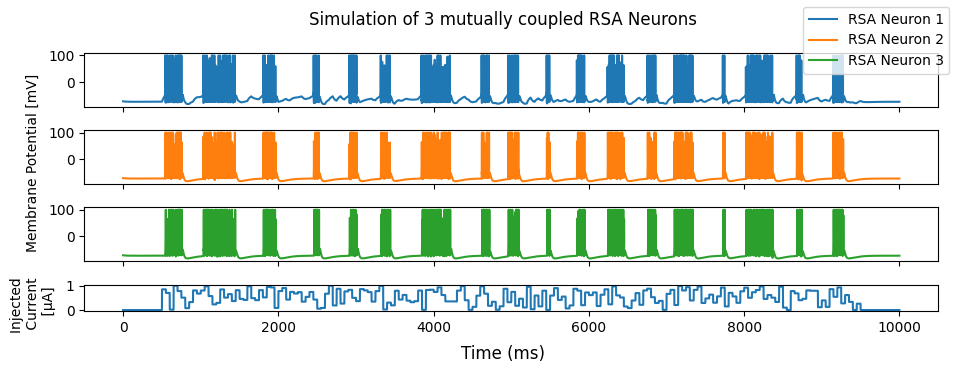

In [14]:
fig, axes = plt.subplots(
    N + 1,
    1,
    sharex=True,
    figsize=(10, N + 1),
    gridspec_kw={"height_ratios": [2] * N + [1]}
)

colors = plt.cm.tab10.colors

all_handles = []
all_labels = []

for i in range(N):
    # Remove constant currents
    if i > 0:
            create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, ns_V_hist, I_ext, all_handles, all_labels, True)
    else:
        create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, ns_V_hist, I_ext, all_handles, all_labels, False)

fig.text(0.08, 0.6, "Membrane Potential [mV]", va="center", ha="center", rotation="vertical")
fig.text(0.08, 0.25, "Injected \n Current \n [µA]", va="center", ha="center", rotation="vertical")
fig.supxlabel("Time (ms)", x=0.55, y=0.1, ha="center")
fig.legend(all_handles, all_labels, loc="upper right")
fig.suptitle("Simulation of 3 mutually coupled RSA Neurons", x=0.55, ha="center")

plt.tight_layout(rect=[0.08, 0.05, 1, 1])
plt.show()

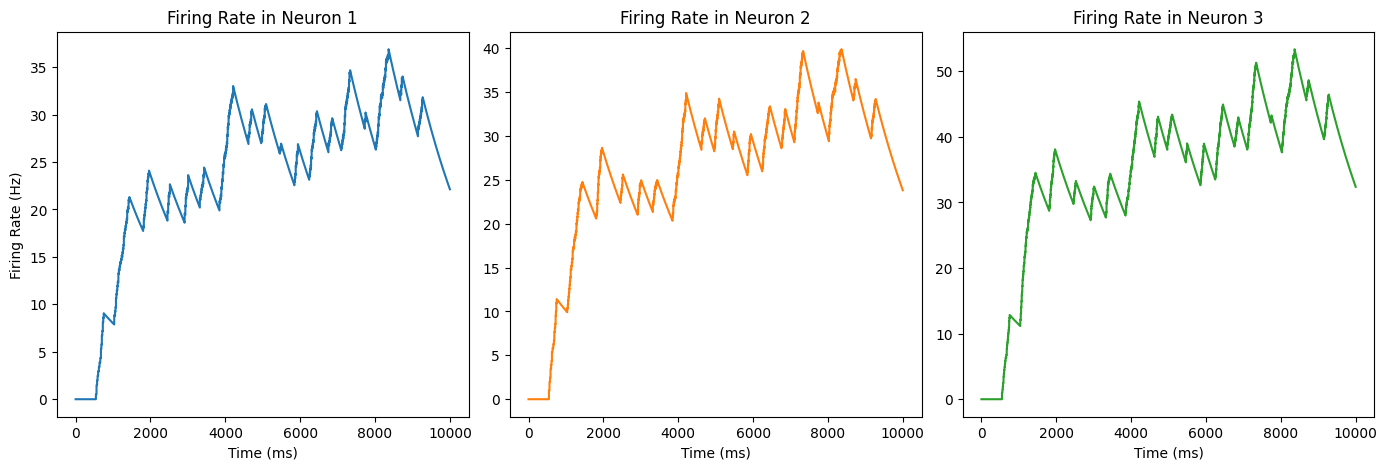

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i in range(N):
    create_comparison_plots(i, axes, colors, times[:-1], ns_spike_ema_Hz_hist[:, i], f"Firing Rate in Neuron {i+1}", "Firing Rate (Hz)")

plt.subplots_adjust(wspace=0.1)

## 2. Same set up as in Part 1 WITH synaptic scaling

In [16]:
N_FS = 0                    # number of FS neurons
N_RSA = 3                   # number of RSA neurons
N_IB = 0                    # number of IB neurons
N = N_FS + N_RSA +  N_IB    # number of neurons in the network

# SEED for random injection current choices
SEED = 505

neuron_types = (
    ["FS"] * N_FS +
    ["RSA"] * N_RSA +
    ["IB"] * N_IB
)

C_M     = generate_simulation_params(NEURON_TYPE_PARAMS["C_M"], neuron_types)
g_bar_K = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_K"], neuron_types)
g_bar_M = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_M"], neuron_types)
g_bar_Ca= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Ca"], neuron_types)
g_bar_Na= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Na"], neuron_types)
g_L     = generate_simulation_params(NEURON_TYPE_PARAMS["g_L"], neuron_types)

tau_max = generate_simulation_params(NEURON_TYPE_PARAMS["tau_max"], neuron_types)

V_K     = generate_simulation_params(NEURON_TYPE_PARAMS["V_K"], neuron_types)
V_Ca    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Ca"], neuron_types)
V_Na    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Na"], neuron_types)
V_L     = generate_simulation_params(NEURON_TYPE_PARAMS["V_L"], neuron_types)
V_T     = generate_simulation_params(NEURON_TYPE_PARAMS["V_T"], neuron_types)

tau_r   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_r"], neuron_types)
tau_d   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_d"], neuron_types)
V_syn   = generate_simulation_params(NEURON_TYPE_PARAMS["V_syn"], neuron_types)
V_0     = generate_simulation_params(NEURON_TYPE_PARAMS["V_0"], neuron_types)

# Adjacency matrices describing the electrical synapses
A_el = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])
degrees_el = np.sum(A_el, axis=1)
D_el = np.diag(degrees_el)
L_el = D_el - A_el

# Chemical synapses allow for self-loops
A_ch = np.array([
    [0, 0, 0.1],
    [0.2, 0, 0],
    [0, 0.22, 0]
])
degrees_ch = np.sum(A_ch, axis=1)
D_ch = np.diag(degrees_ch)
L_ch = D_ch - A_ch

# Selection vector to determine which neurons receive external current
S = np.array([[1], [0], [0]])

# Time parameters
dt = 0.1                # Time step size
total_time = 10000.0     # Total Time to run the experiment for (ms)
times = np.arange(0.0, total_time + dt, dt)
cur_start_time = 500.0
cur_stop_time = 9500.0

# Injected Current
block_time = 50.0
I_inj = random_injection_current(seed=SEED, times=times, start=cur_start_time, stop=cur_stop_time, max_amplitude=1, block_time=block_time)

# External Current
I_ext = S * I_inj

V_init = V_L.copy()

# Steady state initial concentrations for the gates
alpha_n, beta_n = get_rates("n", V_init, V_T)
n_init =  alpha_n / (alpha_n + beta_n)

alpha_m, beta_m = get_rates("m", V_init, V_T)
m_init = alpha_m / (alpha_m + beta_m)

alpha_h, beta_h = get_rates("h", V_init, V_T)
h_init = alpha_h / (alpha_h + beta_h)

p_init = get_p_inf(V_init)

alpha_q, beta_q = get_rates("q", V_init, V_T)
q_init = alpha_q / (alpha_q + beta_q)

alpha_s, beta_s = get_rates("s", V_init, V_T)
s_init = alpha_s / (alpha_s + beta_s)

r_init = np.zeros((N, 1))

voltage_threshold = -20
target_firing_rate = 5

mutually_coupled_with_scaling = HeterogeneousHH(
    N, C_M, g_bar_K, g_bar_M, g_bar_Ca, g_bar_Na, g_L,
    V_K, V_Ca, V_Na, V_L, V_T, V_syn,
    tau_max, tau_r, tau_d, V_0,
    L_el, A_ch,
    V_init, n_init, m_init, h_init,
    p_init, q_init, s_init, r_init,
    True, voltage_threshold, target_firing_rate
)

# Run experiment
mutually_coupled_with_scaling.run_simulation(dt, I_ext)

ws_V_hist = np.array(mutually_coupled_with_scaling.V_history)
ws_A_ch_hist = np.array(mutually_coupled_with_scaling.A_ch_history)
ws_spike_ema_Hz_hist = np.array(mutually_coupled_with_scaling.spike_ema_Hz_history)
ws_scaling_factor_hist = np.array(mutually_coupled_with_scaling.scaling_factor_history)

  0%|          | 0/100000 [00:00<?, ?it/s]

#### View changes in synaptic connections ($\epsilon_{12}^{ch}$ and $\epsilon_{21}^{ch}$)

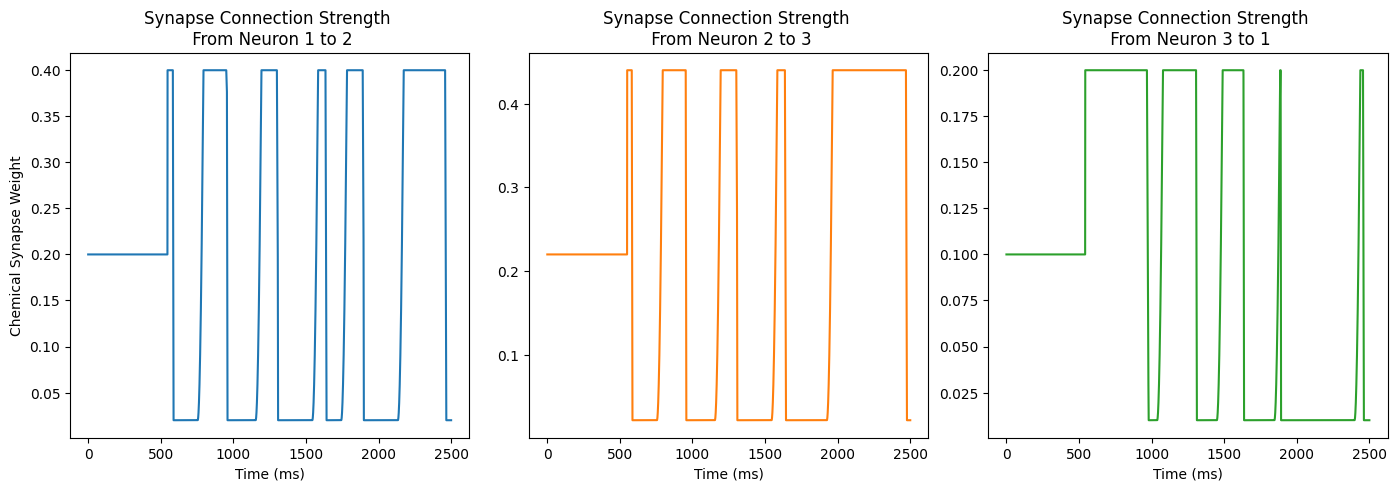

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
create_comparison_plots(0, axes, colors, times[:25000], ws_A_ch_hist[:25000, 1, 0], "Synapse Connection Strength \n From Neuron 1 to 2", "Chemical Synapse Weight")
create_comparison_plots(1, axes, colors, times[:25000], ws_A_ch_hist[:25000, 2, 1], "Synapse Connection Strength \n From Neuron 2 to 3", "Chemical Synapse Weight")
create_comparison_plots(2, axes, colors, times[:25000], ws_A_ch_hist[:25000, 0, 2], "Synapse Connection Strength \n From Neuron 3 to 1", "Chemical Synapse Weight")

plt.subplots_adjust(wspace=0.15)

#### View Changes in Firing Rate

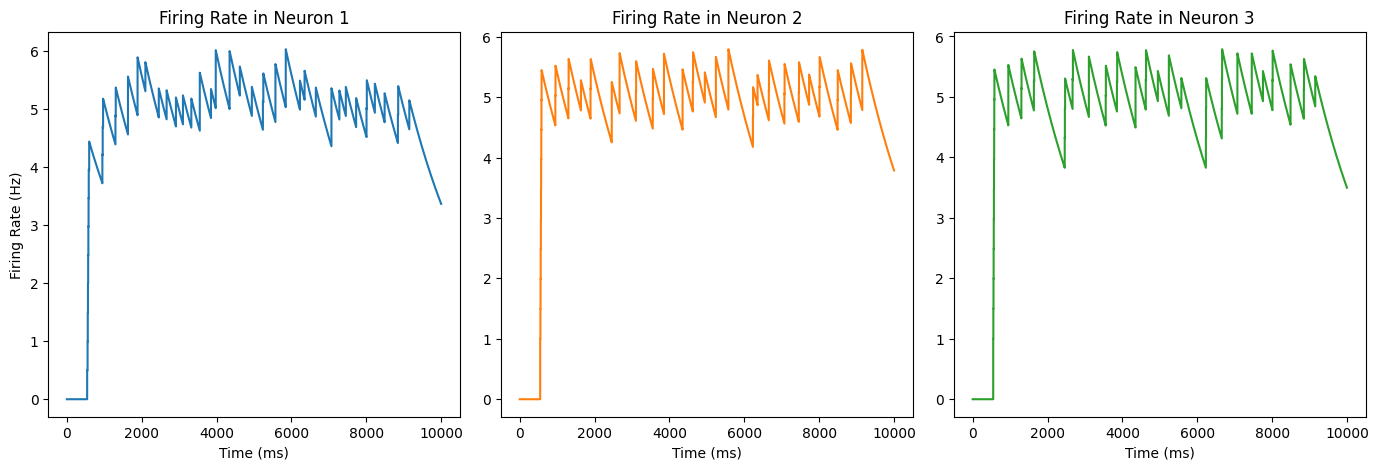

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i in range(N):
    create_comparison_plots(i, axes, colors, times[:-1], ws_spike_ema_Hz_hist[:, i], f"Firing Rate in Neuron {i+1}", "Firing Rate (Hz)")

plt.subplots_adjust(wspace=0.1)

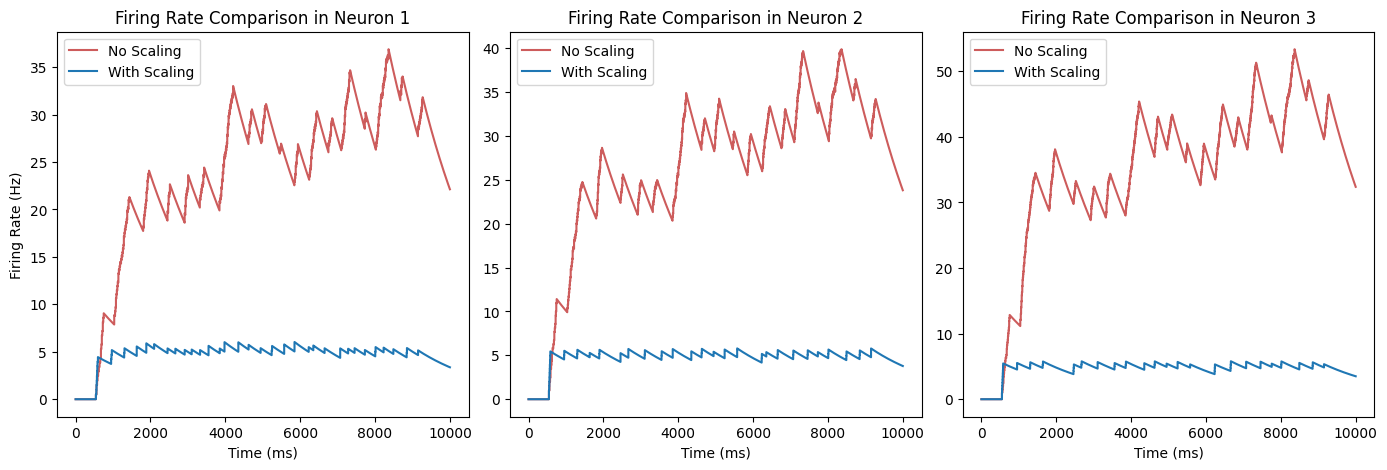

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i in range(N):
    create_overlap_comparison_plots(
        i, axes, colors, times[:-1],
        ns_spike_ema_Hz_hist[:, i], "No Scaling",
        ws_spike_ema_Hz_hist[:, i], "With Scaling",
        f"Firing Rate Comparison in Neuron {i+1}", "Firing Rate (Hz)"
    )

plt.subplots_adjust(wspace=0.1)

#### View changes in scaling factor

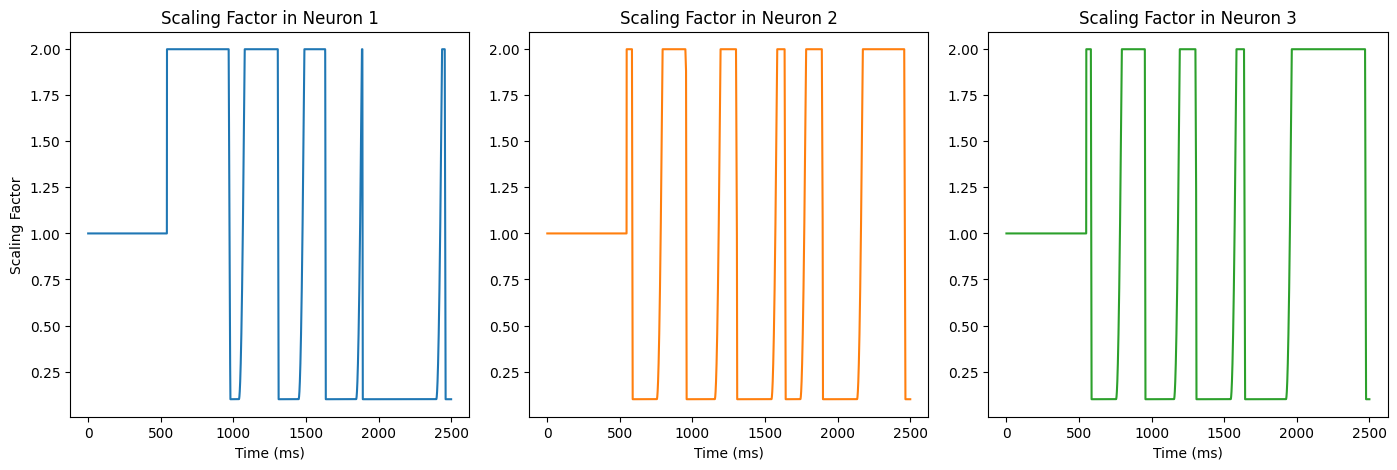

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
create_comparison_plots(0, axes, colors, times[:25000], ws_scaling_factor_hist[:25000, 0], "Scaling Factor in Neuron 1", "Scaling Factor")
create_comparison_plots(1, axes, colors, times[:25000], ws_scaling_factor_hist[:25000, 1], "Scaling Factor in Neuron 2", "Scaling Factor")
create_comparison_plots(2, axes, colors, times[:25000], ws_scaling_factor_hist[:25000, 2], "Scaling Factor in Neuron 3", "Scaling Factor")

plt.subplots_adjust(wspace=0.15)

#### Note that the spikes are much more sparse due to the synaptic scaling

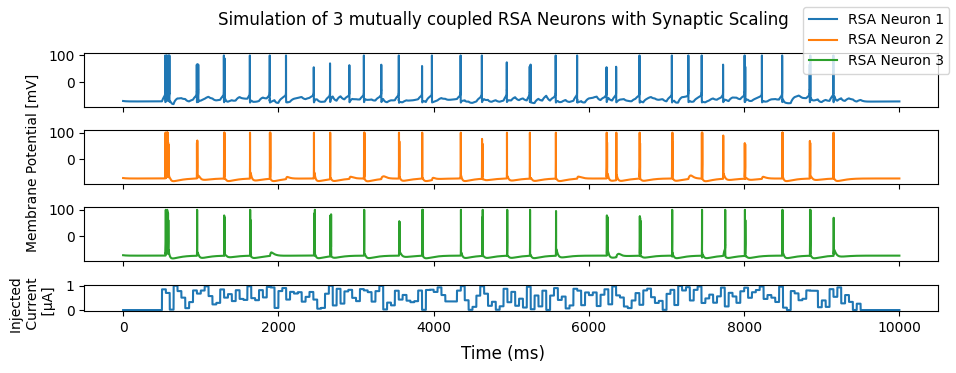

In [21]:
fig, axes = plt.subplots(
    N + 1,
    1,
    sharex=True,
    figsize=(10, N + 1),
    gridspec_kw={"height_ratios": [2] * N + [1]}
)

colors = plt.cm.tab10.colors

all_handles = []
all_labels = []

for i in range(N):
    # Remove constant currents
    if i > 0:
            create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, ws_V_hist, I_ext, all_handles, all_labels, True)
    else:
        create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, ws_V_hist, I_ext, all_handles, all_labels, False)

fig.text(0.08, 0.6, "Membrane Potential [mV]", va="center", ha="center", rotation="vertical")
fig.text(0.08, 0.25, "Injected \n Current \n [µA]", va="center", ha="center", rotation="vertical")
fig.supxlabel("Time (ms)", x=0.55, y=0.1, ha="center")
fig.legend(all_handles, all_labels, loc="upper right")
fig.suptitle("Simulation of 3 mutually coupled RSA Neurons with Synaptic Scaling", x=0.55, ha="center")

plt.tight_layout(rect=[0.08, 0.05, 1, 1])
plt.show()